In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Question 1. Fitting Gravitational Acceleration Using χ2 Mini-mization

In [3]:
t = np.arange(0.1, 1.1, 0.1)
y = np.array([0.051, 0.185, 0.460, 0.810, 1.210, 1.820, 2.440, 3.150, 4.070, 5.100])
sigma = np.array([0.006, 0.007, 0.005, 0.008, 0.006, 0.007, 0.005, 0.009, 0.006, 0.007])

<ErrorbarContainer object of 3 artists>

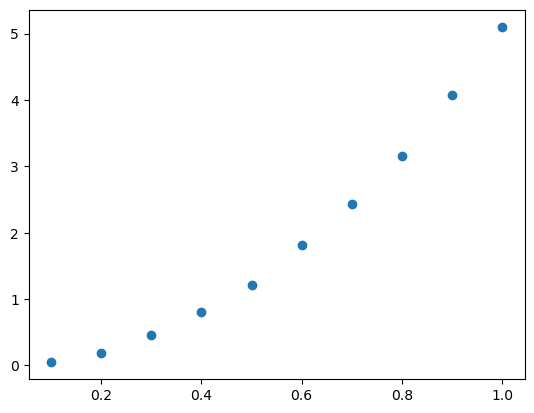

In [4]:
plt.errorbar(t, y, yerr = sigma, marker = 'o', linestyle = ' ')

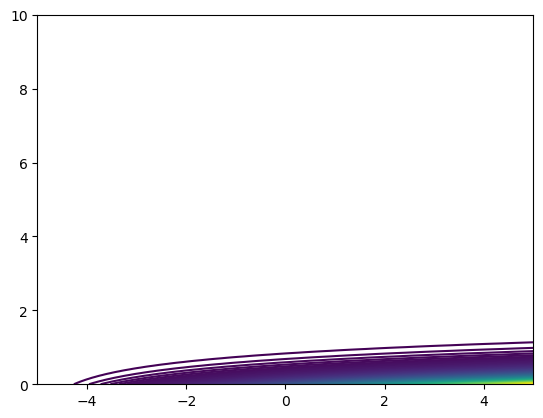

In [16]:
t = np.arange(0.1, 1.1, 0.1)
y = np.array([0.051, 0.185, 0.460, 0.810, 1.210, 1.820, 2.440, 3.150, 4.070, 5.100])
sigma = np.array([0.006, 0.007, 0.005, 0.008, 0.006, 0.007, 0.005, 0.009, 0.006, 0.007])
w = 1/sigma**2
n = 200
m_vals = np.linspace(-5, 5, n)
c_vals = np.linspace(0, 10, n)
S = np.zeros((len(m_vals),len(c_vals)))
for i in range(len(m_vals)):
    for j in range(len(c_vals)):
        y_model = c_vals[j]*(t**m_vals[i])
        S[i,j] = np.sum((w*(y-y_model)**2))
plt.contour(m_vals,c_vals,S,200)        

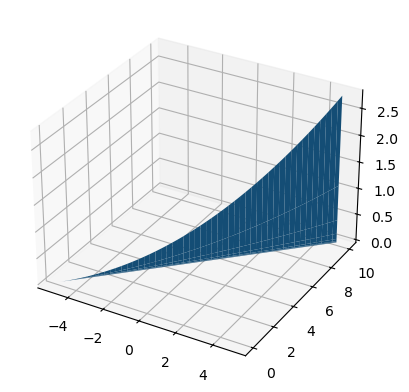

In [17]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(m_vals, c_vals, S)
plt.show()

Best slope = 5.075376884422111
Best intercept = 2.035175879396985


<ErrorbarContainer object of 3 artists>

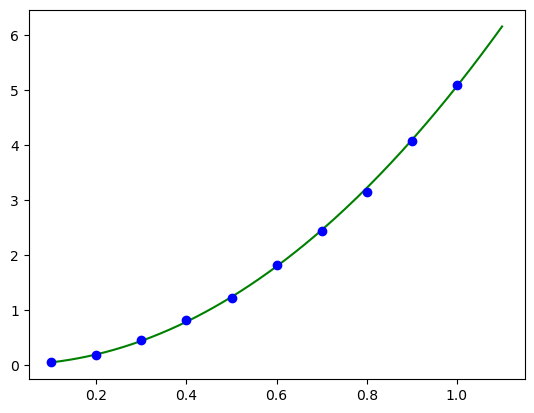

In [18]:
idx = np.unravel_index(np.argmin(S),S.shape)
intercept = c_vals[idx[1]]
slope = m_vals[idx[0]]
print(
    f'Best slope = {intercept}\n'
    f'Best intercept = {slope}'
)
tfit = np.linspace(np.min(t),np.max(t)+0.1, n)
yfit = intercept*(tfit**slope)
plt.plot(tfit, yfit, color = 'g')
plt.errorbar(t,y, yerr = sigma, linestyle = ' ', marker = 'o',color = 'b', ecolor='black')

### Question 2. Fit a line through the data

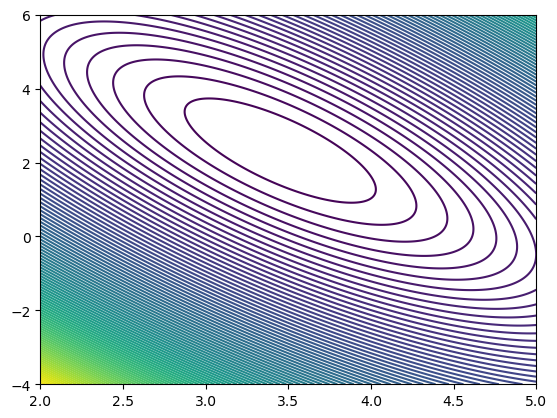

Best slope = 2.3326653306613228
Best intercept = 3.4488977955911824


In [36]:
x = np.arange(1.0, 11.0, 1.0)
y = np.array([5.8, 9.5, 12.4, 15.9, 19.5, 23.8, 26.5, 29.9, 34.0, 37.2])
sigma = np.array([0.15, 0.30, 0.23, 0.38, 0.30, 0.45, 0.38, 0.53, 0.45, 0.60])
#plt.scatter(x,y)

m_vals = np.linspace(2, 5, 500)
c_vals = np.linspace(-4, 6, 500)
S = np.zeros((len(c_vals), len(m_vals)))
for i in range(len(m_vals)):
    for j in range(len(c_vals)):
        y_model = m_vals[i]*x + c_vals[j]
        S[j,i] = np.sum(((y - y_model)/sigma**2)**2)
plt.contour(m_vals, c_vals, S, 100)
plt.show()

idx = np.unravel_index(np.argmin(S),S.shape)
intercept = c_vals[idx[0]]
slope = m_vals[idx[1]]
print(
    f'Best slope = {intercept}\n'
    f'Best intercept = {slope}'
)

<ErrorbarContainer object of 3 artists>

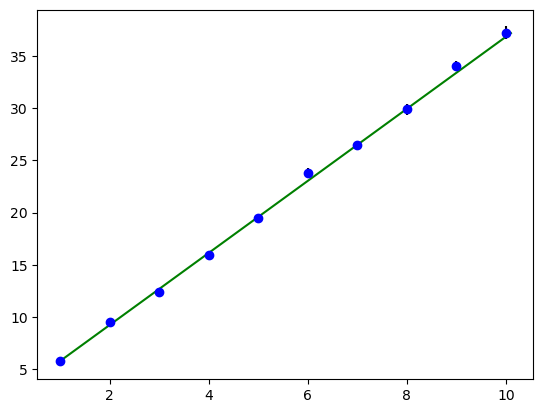

In [37]:
xfit = np.linspace(np.min(x),np.max(x)+0.1, n)
yfit = slope*xfit+intercept
plt.plot(xfit, yfit, color = 'g')
plt.errorbar(x,y, yerr = sigma, linestyle = ' ', marker = 'o',color = 'b', ecolor='black')

### Question 3. “Yeh Coin Mujhe De De, Jai”

[0.01956888 0.03786213 0.07234489 0.13495912 0.23518501 0.37898987
 0.54672595 0.70371713 0.82621539 0.90244966 0.94951162 0.97334898
 0.9857456  0.99322179 0.9963416  0.99824582 0.99898132 0.99956097
 0.99977093 0.99996372 0.99999853]
For 90% surity the number of consicutive heads must be = 9
For 99% surity the number of consicutive heads must be = 13


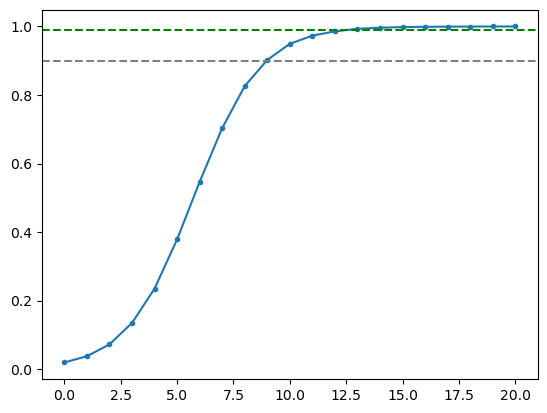

In [21]:
p_fair = 0.5
p_biased = 0.99

prior = 0.5 # part A

experiments = 20000000

max_k = 20

count_k = np.zeros(max_k+1)
count_k_and_biased = np.zeros(max_k+1)

for i in range(experiments):
    if np.random.rand() < prior:
        p = p_biased
        is_biased = True
    else:
        p = p_fair
        is_biased = False

    count_heads = 0
    while np.random.rand() <= p:
        count_heads += 1
        if count_heads >= max_k:
            break

    count_k[count_heads] += 1
    if is_biased:
        count_k_and_biased[count_heads] += 1
plt.plot(np.arange(max_k+1), count_k_and_biased/count_k, marker = '.')
plt.axhline(y=0.90, color='gray', linestyle='--', label='90% Certainty')
plt.axhline(y=0.99, color='green', linestyle='--', label='99% Certainty')
print(count_k_and_biased/count_k)
for i in range(len(count_k_and_biased)):
    if count_k_and_biased[i]/count_k[i] > 0.90:
        print('For 90% surity the number of consicutive heads must be =',i)
        break
for i in range(len(count_k_and_biased)):        
    if count_k_and_biased[i]/count_k[i] > 0.99:
        print('For 99% surity the number of consicutive heads must be =',i)
        break    

[0.00222275 0.00441551 0.008695   0.01696029 0.03333047 0.06279858
 0.11850562 0.21003071 0.34157039 0.50472595 0.67233322 0.80489463
 0.89292706 0.93963057 0.96987247 0.98464193 0.99152936 0.99615134
 0.99789144 0.99880103 0.99998288]
For 90% surity the number of consicutive heads must be = 13
For 99% surity the number of consicutive heads must be = 16


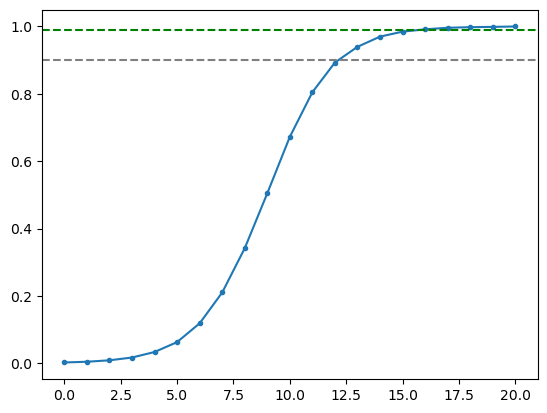

In [22]:
p_fair = 0.5
p_biased = 0.99

prior = 0.1 # part A

experiments = 20000000

max_k = 20

count_k = np.zeros(max_k+1)
count_k_and_biased = np.zeros(max_k+1)

for i in range(experiments):
    if np.random.rand() < prior:
        p = p_biased
        is_biased = True
    else:
        p = p_fair
        is_biased = False

    count_heads = 0
    while np.random.rand() <= p:
        count_heads += 1
        if count_heads >= max_k:
            break

    count_k[count_heads] += 1
    if is_biased:
        count_k_and_biased[count_heads] += 1
plt.plot(np.arange(max_k+1), count_k_and_biased/count_k, marker = '.')
plt.axhline(y=0.90, color='gray', linestyle='--', label='90% Certainty')
plt.axhline(y=0.99, color='green', linestyle='--', label='99% Certainty')
print(count_k_and_biased/count_k)
for i in range(len(count_k_and_biased)):
    if count_k_and_biased[i]/count_k[i] > 0.90:
        print('For 90% surity the number of consicutive heads must be =',i)
        break
for i in range(len(count_k_and_biased)):        
    if count_k_and_biased[i]/count_k[i] > 0.99:
        print('For 99% surity the number of consicutive heads must be =',i)
        break    